# 📧 업무 메일 자동 분류 시스템
## 전체 흐름
```
1. IMAP 접속
2. 메일 가져오기
3. 제목 / 발신자 / 본문 / PDF 텍스트 추출
4. 형태소 분석기 4개 비교 → 최적 분석기 선택 → 정보 추출
5. 메일별 워드클라우드 + PDF 카테고리 이동 + CSV 저장
```

---
# 1편. IMAP 접속 확인

## 라이브러리 설치

In [1]:
# !pip install pdfplumber konlpy wordcloud scikit-learn nltk

## 계정 입력

In [ ]:
EMAIL = "아이디"
PASSWORD = "앱_비밀번호"  # 앱 비밀번호 16자리

## Gmail 접속

In [3]:
import imaplib

mail = imaplib.IMAP4_SSL("imap.gmail.com")
mail.login(EMAIL, PASSWORD)
print("✅ 접속 성공")

✅ 접속 성공


---
# 2편. 메일 가져오기

## 메일 기간 설정 및 목록 조회

In [4]:
from datetime import datetime, timedelta

mail.select("INBOX")

# ── 전체 메일 ──────────────────────────────
_, msg_nums = mail.search(None, "ALL")

# ── 최근 1일 ──────────────────────────────
# since_date = (datetime.now() - timedelta(days=1)).strftime("%d-%b-%Y")
# _, msg_nums = mail.search(None, f'SINCE {since_date}')

# ── 최근 7일 ──────────────────────────────
# since_date = (datetime.now() - timedelta(days=7)).strftime("%d-%b-%Y")
# _, msg_nums = mail.search(None, f'SINCE {since_date}')

num_list = msg_nums[0].split()
print(f"📧 메일 수: {len(num_list)}건")

📧 메일 수: 12건


## 디코딩 함수 정의

In [5]:
import email
import pandas as pd
from email.header import decode_header

# 디코딩 함수 : 제목, 발신자, 파일명 등 바이트 → 문자열
def decode_str(s):
    if s is None:
        return ""
    result = ""
    for part, enc in decode_header(s):
        if isinstance(part, bytes):
            result += part.decode(enc or "utf-8", errors="ignore")
        else:
            result += str(part)
    return result

---
# 3편. 텍스트 추출

## PDF 텍스트 추출 함수

In [6]:
import pdfplumber
import os

def extract_pdf_text(filepath):
    text = ""
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
    except Exception as e:
        text = f"[추출 실패: {e}]"
    return text.strip()

## 메일 본문 추출 함수

In [7]:
def get_body(msg):
    for part in msg.walk():
        if part.get_content_type() == "text/plain":
            if "attachment" not in str(part.get("Content-Disposition", "")):
                try:
                    return part.get_payload(decode=True).decode("utf-8", errors="ignore")
                except:
                    pass
    return ""

## PDF 다운로드 함수

In [8]:
DOWNLOAD_DIR = "downloads"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

def get_pdfs(msg):
    pdf_text, pdfs = "", []
    for part in msg.walk():
        if "attachment" in str(part.get("Content-Disposition", "")):
            filename = part.get_filename()
            if filename:
                filename = decode_str(filename)
                if filename.lower().endswith(".pdf"):
                    filepath = os.path.join(DOWNLOAD_DIR, filename)
                    with open(filepath, "wb") as f:
                        f.write(part.get_payload(decode=True))
                    pdf_text += extract_pdf_text(filepath)
                    pdfs.append(filepath)
    return pdf_text, pdfs

## 메일 데이터 수집

In [9]:
results = []

for num in num_list[::-1]:
    _, data = mail.fetch(num, "(RFC822)")
    msg = email.message_from_bytes(data[0][1])
    pdf_text, pdfs = get_pdfs(msg)
    results.append({
        "subject":   decode_str(msg["Subject"]),   # 제목
        "sender":    decode_str(msg["From"]),      # 발신자
        "body":      get_body(msg).strip(),        # 본문
        "pdf_text":  pdf_text.strip(),             # PDF 텍스트
        "pdf_paths": pdfs,                         # PDF 저장 경로 목록
    })

print(f"✅ {len(results)}건 수집 완료")

✅ 12건 수집 완료


## 결과 확인

In [10]:
df_check = pd.DataFrame(results)
df_check["body_len"]  = df_check["body"].apply(len)
df_check["pdf_len"]   = df_check["pdf_text"].apply(len)
df_check["pdf_count"] = df_check["pdf_paths"].apply(len)
print(df_check[["subject", "sender", "body_len", "pdf_len", "pdf_count"]])

                                           subject  \
0                [보고서] 4월 서비스 데이터 분석 종합 보고서 초안입니다.   
1                                     일정 변경 공지입니다.   
2                              참석자분들께 회의록 배포해드립니다.   
3                                    회의 결과 보고드립니다.   
4                            안내받은 바에 따라 협조 요청드립니다.   
5                                            보안 알림   
6                                  프라치노 공책 거래 영수증t   
7                                        프라치노 공책주문   
8                             Re: [업무협조] 데이터 검증 요청   
9                                 [업무협조] 데이터 검증 요청   
10                                 [업무협조] 기능 검토 요청   
11  발표자료 - 배경 따릉이 이용 데이터는 공개되어 있지만, CSV 형태의 원시 ...   

                                               sender  body_len  pdf_len  \
0                           민석 <mhnkms8041@gmail.com>        33     1611   
1                           민석 <mhnkms8041@gmail.com>        56      128   
2                           민석 <mhnkms8041@gmail.com>        12      

## 접속 종료

In [11]:
mail.logout()
print("👋 접속 종료")

👋 접속 종료


---
# 4편. 형태소 분석기 비교 및 분류

## 형태소 분석기 로드

In [12]:
from konlpy.tag import Okt, Komoran, Kkma, Hannanum

okt      = Okt()
komoran  = Komoran()
kkma     = Kkma()
hannanum = Hannanum()

print("✅ 분석기 로드 완료")

✅ 분석기 로드 완료


## 불용어 및 카테고리 키워드 정의

In [13]:
STOPWORDS = set([
    "합니다", "있습니다", "드립니다", "바랍니다", "부탁드립니다", "니다", "이다",
    "안녕하세요", "감사합니다", "관련", "내용",
    "진행", "경우", "이번", "해당", "통해", "위해", "대해", "파일", "것", "수", "때", "후", "전", "중", "등", "및"
])

CATEGORIES = {
        "업무협조": [
            "협조", "요청", "부탁", "전달", "회신", "확인", "처리", "검토", "승인", "진행", "지원", "일청 요청", "자료 요청", "공유 요청", "확인 부탁", "전달 부탁"
        ],
        "보고서": [
            "보고", "결과", "분석", "현황", "매출", "데이터", "통계", "성과", "개선", "지표", "리포트", "요약"
        ],
        "회의록": [
            "회의", "회의록", "안건", "참석자", "일정", "논의", "결정", "진행", "의결", "회의 결과"
        ],
        "공지": [
            "공지", "안내", "알림", "변경", "일정", "공지사항", "배포", "적용", "공지드립니다", "참고"
        ]
    }

## 명사 추출 함수

In [14]:
def extract_nouns(text, analyzer):
    if not text or not text.strip():
        return []
    try:
        # Kkma, Komoran → NNG(일반명사)만 추출
        if isinstance(analyzer, (Kkma, Komoran)):
            tagged = analyzer.pos(text)
            nouns = [word for word, tag in tagged if tag == "NNG" and len(word) >= 2]
        # Okt, Hannanum → nouns() 그대로 사용
        else:
            nouns = analyzer.nouns(text)
            nouns = [n for n in nouns if len(n) >= 2]

        nouns = [n for n in nouns if n not in STOPWORDS]
        return nouns
    except Exception:
        return []

# 분석기별 명사 추출 테스트
sample = "업무협조 요청드립니다. 첨부파일 검토 후 회신 부탁드립니다."
print(f"Okt      : {extract_nouns(sample, okt)}")
print(f"Komoran  : {extract_nouns(sample, komoran)}")
print(f"Kkma     : {extract_nouns(sample, kkma)}")
print(f"Hannanum : {extract_nouns(sample, hannanum)}")

Okt      : ['업무', '협조', '요청', '첨부파일', '검토', '회신']
Komoran  : ['업무', '협조', '요청', '검토', '회신', '부탁']
Kkma     : ['업무', '협조', '요청', '첨부파일', '검토', '회신', '부탁']
Hannanum : ['업무협조', '요청드', '첨부파', '검토']


## 회신 / 기한 / 요약 추출 함수

In [15]:
import re

ACTION_KEYWORDS = [
    "부탁드립니다", "확인 바랍니다", "회신 바랍니다",
    "검토 부탁", "처리 부탁", "승인 요청", "확인 부탁", "회신바랍니다"
]

DEADLINE_PATTERNS = [
    r"\d+일\s*내",
    r"\d{1,2}월\s*\d{1,2}일까지",
    r"\d{4}-\d{2}-\d{2}까지",
    r"\d+/\d+\s*\(.*?\)까지",
    r"\d+/\d+까지",
    r"오늘\s*중",
    r"내일까지",
    r"금주\s*내",
    r"이번\s*주\s*내",
    r"긴급|즉시|빠른\s*시일",
]

def detect_action(text):
    return "필요" if any(kw in text for kw in ACTION_KEYWORDS) else "불필요"

def find_deadline(text):
    for pattern in DEADLINE_PATTERNS:
        m = re.search(pattern, text)
        if m:
            return m.group(0)
    return "-"

def make_summary(body):
    sentences = [s.strip() for s in re.split(r'[.\n]', body) if len(s.strip()) > 5]
    return " / ".join(sentences[:2]) if sentences else "-"

## 방법 1: KoNLPy + FreqDist (빈도 분석) 분류 함수

In [16]:
from nltk import FreqDist

TAG_MAP = {
    "[업무협조]": "업무협조",
    "[보고서]":   "보고서",  
    "[회의록]":   "회의록",
    "[공지]":     "공지",
}

def classify_freqdist(text, analyzer, subject=""):
    """
    명사 추출 → FreqDist 빈도 분석
    → 카테고리 키워드와 겹치는 빈도 합산
    → 가장 높은 카테고리로 분류
    """

     # 제목 태그 우선 확인
    for tag, cat in TAG_MAP.items():
        if tag in subject:
            return cat, 1.0  # 태그 있으면 신뢰도 100%
    
    # 태그 없으면 FreqDist로 분류
    nouns = extract_nouns(text, analyzer)
    if not nouns:
        return "기타", 0.0
    fd = FreqDist(nouns)
    scores = {cat: sum(fd[kw] for kw in kws) for cat, kws in CATEGORIES.items()}
    total = sum(scores.values())
    if total == 0:
        return "기타", 0.0
    best = max(scores, key=scores.get)
    confidence = round(scores[best] / total, 2)
    return best, confidence

## 방법 2: KoNLPy + TF-IDF (단어 가중치) 분류 함수

- 자주 나오지만 여러 문서에 흔한 단어는 낮게, 특정 문서에서만 자주 나오는 단어는 높게 가중치를 주는 방식

- TF  = 이 문서에서 단어가 나온 비율
- IDF = 전체 문서 중 이 단어가 없는 문서가 많을수록 높음

- TF-IDF = TF × IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def classify_tfidf(text, analyzer, subject=""):
    """
    명사 추출 → TF-IDF 수치화
    → 카테고리 키워드와 단어 가중치 비교
    → 가장 높은 카테고리로 분류
    """
    
     # 제목 태그 우선 확인
    for tag, cat in TAG_MAP.items():
        if tag in subject:
            return cat, 1.0  # 태그 있으면 신뢰도 100%
    
    # 태그 없으면 FreqDist로 분류
    nouns = extract_nouns(text, analyzer)
    if not nouns:
        return "기타", 0.0
    input_doc = " ".join(nouns)
    category_docs = {cat: " ".join(kws) for cat, kws in CATEGORIES.items()}
    docs = [input_doc] + list(category_docs.values())
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(docs)
    input_vec = tfidf_matrix[0].toarray()[0]
    feature_names = vectorizer.get_feature_names_out()
    scores = {}
    for cat, kws in CATEGORIES.items():
        score = sum(
            input_vec[np.where(feature_names == kw)[0][0]]
            for kw in kws if kw in feature_names
        )
        scores[cat] = score
    total = sum(scores.values())
    if total == 0:
        return "기타", 0.0
    best = max(scores, key=scores.get)
    confidence = round(scores[best] / total, 2)
    return best, confidence

## 형태소 분석기 4개 × 분류 방법 2가지 비교 실행
- 형태소 분석기 : Okt, Komoran, Kkma, Hannanum
- 분류 방법 : FreqDist(단어 빈도), TF-IDF(단어 가중치)
- 비교 기준 : 제목만 / 제목+본문 / 제목+본문+PDF 세 가지 경우로 신뢰도 측정
- 목적 : 어떤 분석기와 방법의 조합이 가장 높은 신뢰도를 보이는지 확인

In [18]:
import time

# 형태소 분석기
ANALYZERS = {
    "Okt":      okt,
    "Komoran":  komoran,
    "Kkma":     kkma,
    "Hannanum": hannanum,
}

freqdist_results = {}
tfidf_results    = {}

for name, analyzer in ANALYZERS.items():
    for method, func, store in [
        ("FreqDist", classify_freqdist, freqdist_results),
        ("TF-IDF",   classify_tfidf,   tfidf_results),
    ]:
        print(f"⏳ [{method}] {name} 분석 중...")
        start = time.time()
        rows = []
        for r in results:
            subject   = r["subject"]
            sender    = r["sender"]
            body      = r["body"]
            pdf_text  = r["pdf_text"]
            full_text = subject + " " + body + " " + pdf_text # 제목 + 본문 + PDF 내용을 합친 하나의 문서

            cat1, conf1 = classify_freqdist(subject, analyzer, subject=subject)
            cat2, conf2 = classify_freqdist(subject + " " + body, analyzer, subject=subject)
            cat3, conf3 = classify_freqdist(full_text, analyzer, subject=subject)

            rows.append({
                "제목":             subject,
                "발신자":           sender,
                "분류_제목":        cat1,
                "신뢰도_제목":      conf1,
                "분류_제목+본문":   cat2,
                "신뢰도_제목+본문": conf2,
                "분류_전체":        cat3,
                "신뢰도_전체":      conf3,
                "회신":             detect_action(full_text),
                "기한":             find_deadline(full_text),
                "요약":             make_summary(body),
            })
        elapsed = round(time.time() - start, 2)
        store[name] = {"rows": rows, "time": elapsed}
        print(f"✅ {name} 완료 ({elapsed}초)")

⏳ [FreqDist] Okt 분석 중...
✅ Okt 완료 (0.48초)
⏳ [TF-IDF] Okt 분석 중...
✅ Okt 완료 (0.17초)
⏳ [FreqDist] Komoran 분석 중...
✅ Komoran 완료 (0.1초)
⏳ [TF-IDF] Komoran 분석 중...
✅ Komoran 완료 (0.08초)
⏳ [FreqDist] Kkma 분석 중...
✅ Kkma 완료 (2.03초)
⏳ [TF-IDF] Kkma 분석 중...
✅ Kkma 완료 (0.91초)
⏳ [FreqDist] Hannanum 분석 중...
✅ Hannanum 완료 (1.16초)
⏳ [TF-IDF] Hannanum 분석 중...
✅ Hannanum 완료 (0.64초)


## 분석기별 신뢰도 비교 요약
- 형태소 분석기 4개 × 방법 2가지 결과를 테이블로 정리
- 신뢰도 : 1위 카테고리 점수 / 전체 카테고리 점수 합 (높을수록 분류가 확실함)
- 일치율 : 제목만/제목+본문으로 분류한 결과가 전체(제목+본문+PDF) 기준과 얼마나 일치하는지
- 처리시간 : 분석기별 실행 속도 비교

In [19]:
def make_summary_df(result_dict, method_name):
    rows = []
    for name, data in result_dict.items():
        df = pd.DataFrame(data["rows"])
        same_1 = (df["분류_제목"] == df["분류_전체"]).mean()
        same_2 = (df["분류_제목+본문"] == df["분류_전체"]).mean()
        rows.append({
            "방법":             method_name,
            "분석기":           name,
            "신뢰도_제목":      f"{df['신뢰도_제목'].mean():.2%}",
            "신뢰도_제목+본문": f"{df['신뢰도_제목+본문'].mean():.2%}",
            "신뢰도_전체":      f"{df['신뢰도_전체'].mean():.2%}",
            "일치율_제목":      f"{same_1:.2%}",
            "일치율_제목+본문": f"{same_2:.2%}",
            "처리시간(초)":     data["time"],
        })
    return rows

summary_df = pd.DataFrame(
    make_summary_df(freqdist_results, "FreqDist") +
    make_summary_df(tfidf_results,    "TF-IDF")
)
summary_df

,방법,분석기,신뢰도_제목,신뢰도_제목+본문,신뢰도_전체,일치율_제목,일치율_제목+본문,처리시간(초)
0,FreqDist,Okt,75.75%,62.58%,63.67%,91.67%,100.00%,0.48
1,FreqDist,Komoran,61.17%,49.58%,52.83%,91.67%,100.00%,0.10
2,FreqDist,Kkma,64.67%,61.00%,63.75%,91.67%,100.00%,2.03
3,FreqDist,Hannanum,60.42%,62.08%,64.50%,91.67%,100.00%,1.16
4,TF-IDF,Okt,75.75%,62.58%,63.67%,91.67%,100.00%,0.17
5,TF-IDF,Komoran,61.17%,49.58%,52.83%,91.67%,100.00%,0.08
6,TF-IDF,Kkma,64.67%,61.00%,63.75%,91.67%,100.00%,0.91
7,TF-IDF,Hannanum,60.42%,62.08%,64.50%,91.67%,100.00%,0.64


## 시각화 - 분석기별 신뢰도 비교

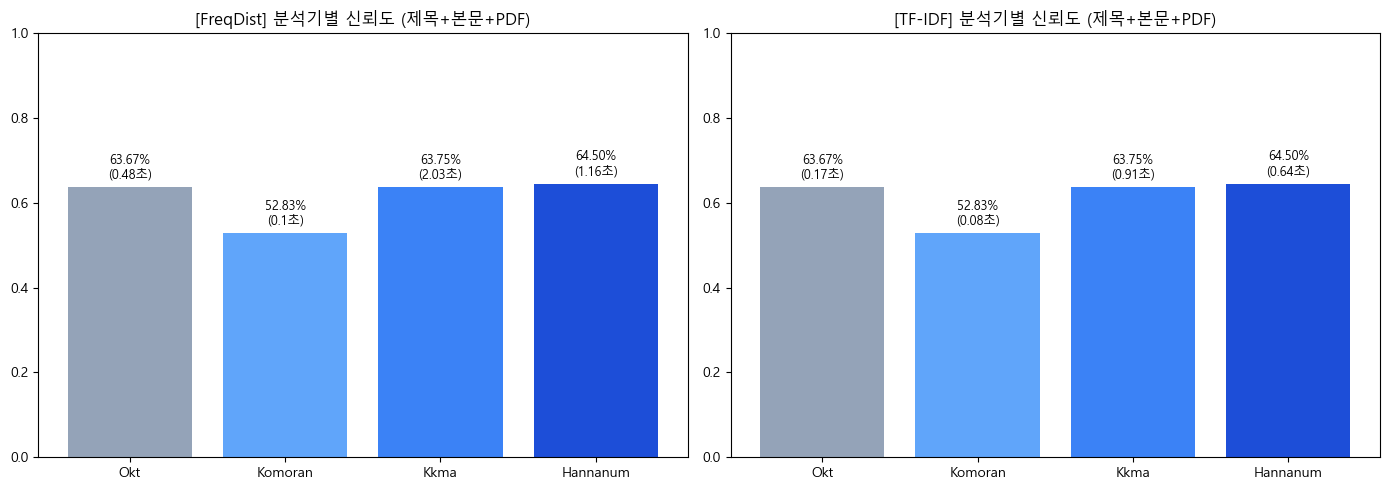

In [20]:
import matplotlib.pyplot as plt
import matplotlib

# matplotlib.rcParams["font.family"] = "AppleGothic"   # Mac
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # Windows
matplotlib.rcParams["axes.unicode_minus"] = False

os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, result_dict) in zip(axes, [
    ("FreqDist", freqdist_results),
    ("TF-IDF",   tfidf_results),
]):
    names     = list(result_dict.keys())
    conf_full = [pd.DataFrame(d["rows"])["신뢰도_전체"].mean() for d in result_dict.values()]
    times     = [d["time"] for d in result_dict.values()]
    x = np.arange(len(names))
    ax.bar(x, conf_full, color=["#94a3b8", "#60a5fa", "#3b82f6", "#1d4ed8"])
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(f"[{method}] 분석기별 신뢰도 (제목+본문+PDF)")
    ax.set_ylim(0, 1)
    for i, (v, t) in enumerate(zip(conf_full, times)):
        ax.text(i, v + 0.02, f"{v:.2%}\n({t}초)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("results/analyzer_compare.png", dpi=150)
plt.show()

## 최적 분석기 자동 선택

In [28]:
# 신뢰도 가장 높은 분석기 자동 선택
# best_analyzer_name = max(
#     freqdist_results.keys(),
#     key=lambda name: pd.DataFrame(freqdist_results[name]["rows"])["신뢰도_전체"].mean()
# )
# print(f"✅ 최적 분석기: {best_analyzer_name}")

# final_results = freqdist_results[best_analyzer_name]["rows"]
# print(f"✅ {len(final_results)}건 분류 완료")


# 자동 선택 대신 Kkma 고정
# best_analyzer_name = "Kkma"
# final_results = freqdist_results["Kkma"]["rows"]
# print(f"✅ 선택 분석기: Kkma")

# 자동 선택 대신 Okt 고정
best_analyzer_name = "Okt"
final_results = freqdist_results["Okt"]["rows"]
print(f"✅ 선택 분석기: Okt (속도 빠르고 명사 추출 정확)")

✅ 선택 분석기: Okt (속도 빠르고 명사 추출 정확)


---
# 5편. 워드클라우드 + PDF 이동 + CSV 저장

## 메일별 워드클라우드

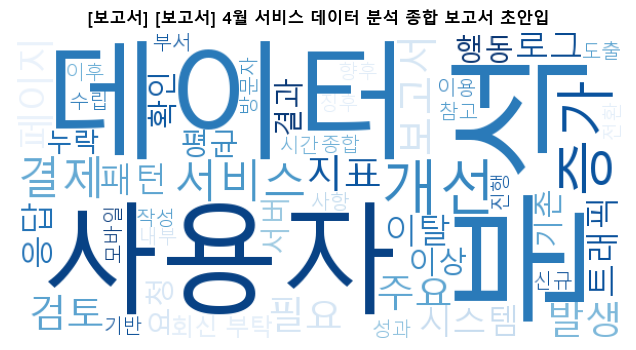

✅ 1. [보고서] [보고서] 4월 서비스 데이터 분석 종합 보고서 초안입


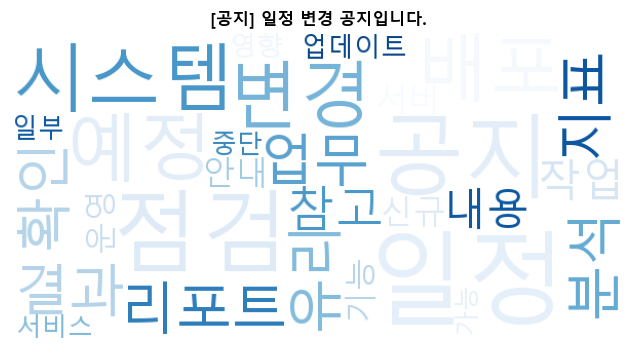

✅ 2. [공지] 일정 변경 공지입니다.


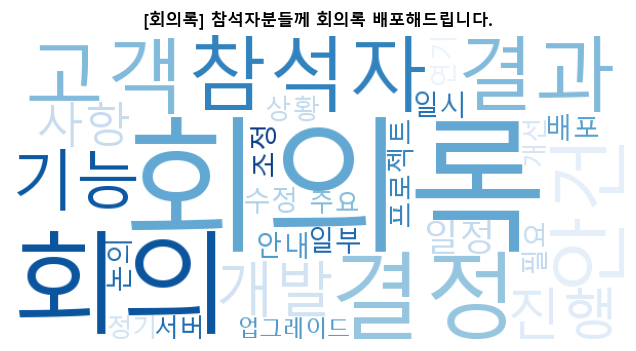

✅ 3. [회의록] 참석자분들께 회의록 배포해드립니다.


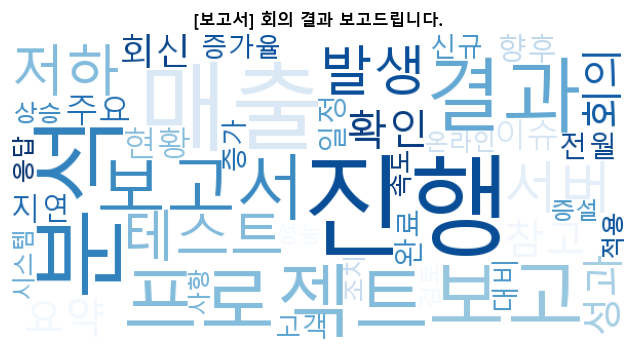

✅ 4. [보고서] 회의 결과 보고드립니다.


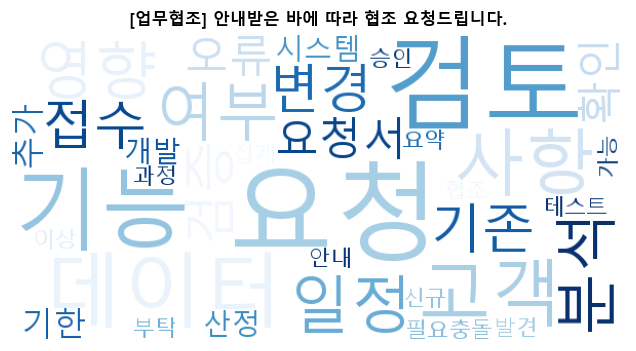

✅ 5. [업무협조] 안내받은 바에 따라 협조 요청드립니다.


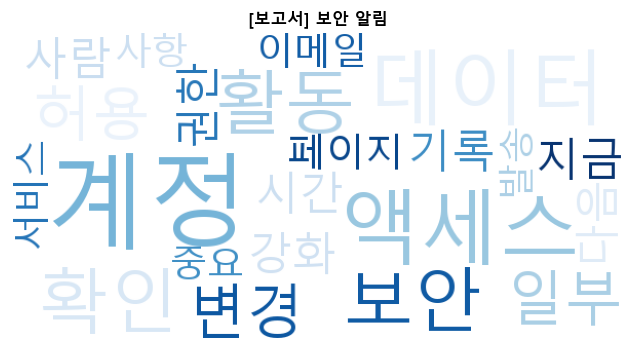

✅ 6. [보고서] 보안 알림


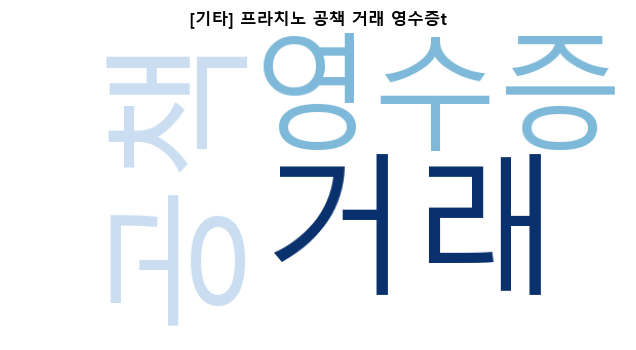

✅ 7. [기타] 프라치노 공책 거래 영수증t


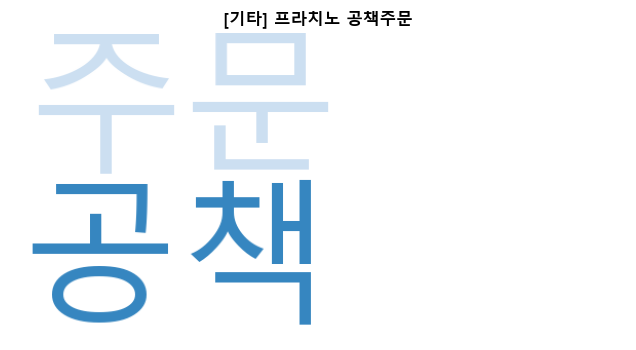

✅ 8. [기타] 프라치노 공책주문


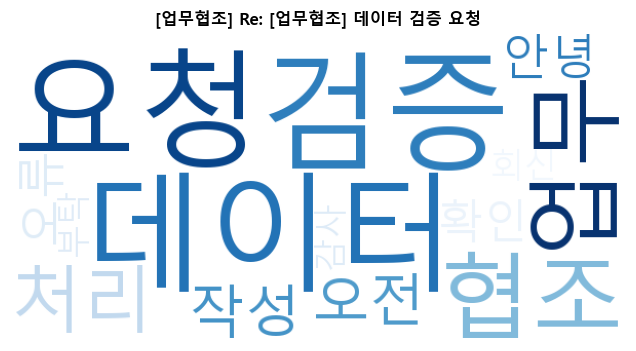

✅ 9. [업무협조] Re: [업무협조] 데이터 검증 요청


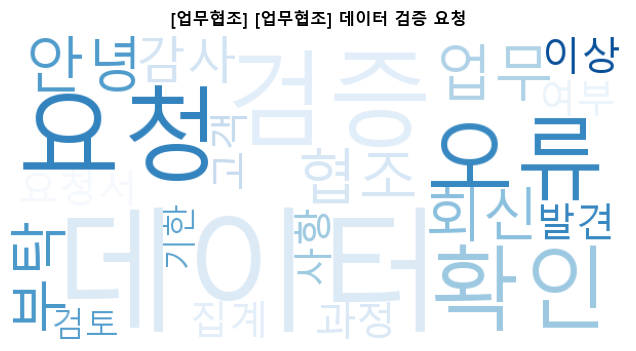

✅ 10. [업무협조] [업무협조] 데이터 검증 요청


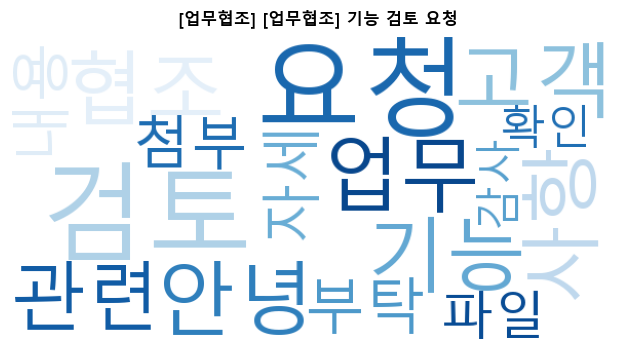

✅ 11. [업무협조] [업무협조] 기능 검토 요청


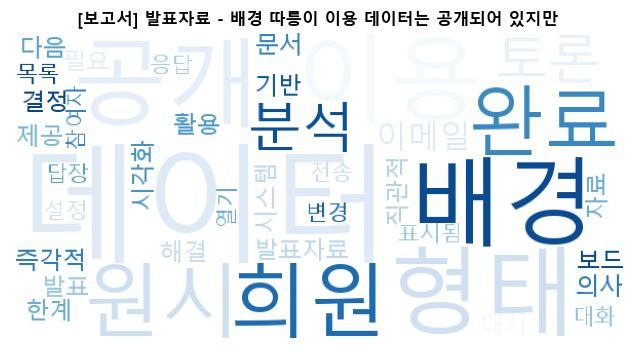

✅ 12. [보고서] 발표자료 - 배경 따릉이 이용 데이터는 공개되어 있지만


In [29]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import os
from wordcloud import WordCloud
from konlpy.tag import Kkma

# matplotlib.rcParams["font.family"] = "AppleGothic"   # Mac
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # Windows
matplotlib.rcParams["axes.unicode_minus"] = False

font_path = "C:/Windows/Fonts/malgun.ttf"        # Windows
# font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # Mac

STOPWORDS_WC = set([
    "합니다", "있습니다", "드립니다", "바랍니다",
    "안녕하세요", "감사합니다", "첨부파일",
])

kkma = Kkma()
os.makedirs("results/wordcloud", exist_ok=True)

for i, (r, row) in enumerate(zip(results, final_results)):
    full_text = r["subject"] + " " + r["body"] + " " + r["pdf_text"]

    # pos()로 품사 태깅 → NNG(일반명사)만 추출 → 고유명사(NNP) 제외
    tagged = kkma.pos(full_text) if full_text.strip() else []
    nouns = [word for word, tag in tagged if tag == "NNG" and len(word) >= 2]
    nouns = [n for n in nouns if n not in STOPWORDS_WC]

    if not nouns:
        print(f"⚠️ {i+1}. {r['subject'][:30]} - 명사 없음 스킵")
        continue

    wc = WordCloud(
        font_path=font_path,
        background_color="white",
        max_words=50,
        width=600,
        height=300,
        colormap="Blues",
    ).generate(" ".join(nouns))

    plt.figure(figsize=(10, 4))
    plt.imshow(wc)
    plt.axis("off")
    title = f"[{row['분류_전체']}] {r['subject'][:30]}"
    plt.title(title, fontsize=12, fontweight="bold")
    filename = f"results/wordcloud/mail_{i+1:02d}.png"
    plt.savefig(filename, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ {i+1}. {title}")

## PDF 카테고리 폴더 이동

In [23]:
import shutil

DOWNLOAD_DIR = "downloads"
categories = ["업무협조", "보고서", "회의록", "공지", "기타"]
for cat in categories:
    os.makedirs(os.path.join(DOWNLOAD_DIR, cat), exist_ok=True)

for r, row in zip(results, final_results):
    category  = row["분류_전체"]
    pdf_paths = r.get("pdf_paths", [])
    for src_path in pdf_paths:
        if not os.path.exists(src_path):
            print(f"⚠️ 파일 없음: {src_path}")
            continue
        filename = os.path.basename(src_path)
        dst_path = os.path.join(DOWNLOAD_DIR, category, filename)
        shutil.move(src_path, dst_path)
        print(f"📁 {filename} → {category}/")

print("✅ PDF 이동 완료")

📁 26년 4월 서비스 데이터 분석 종합 보고서.pdf → 보고서/
📁 mail10_notice.pdf → 공지/
📁 mail11_notice.pdf → 공지/
📁 mail12_notice.pdf → 공지/
📁 mail7_meeting.pdf → 회의록/
📁 mail8_meeting.pdf → 회의록/
📁 mail9_meeting.pdf → 회의록/
📁 mail4_report.pdf → 보고서/
📁 mail5_report.pdf → 보고서/
📁 mail6_report.pdf → 보고서/
📁 mail3_request.pdf → 업무협조/
📁 mail2_request.pdf → 업무협조/
📁 mail1_request.pdf → 업무협조/
⚠️ 파일 없음: downloads\mail2_request.pdf
⚠️ 파일 없음: downloads\mail1_request.pdf
✅ PDF 이동 완료


## CSV 저장

In [24]:
df = pd.DataFrame(final_results)
os.makedirs("results", exist_ok=True)

columns = ["제목", "발신자", "분류_전체", "신뢰도_전체", "회신", "기한", "요약"]
df[columns].to_csv("results/mail_classify_result.csv", index=False, encoding="utf-8-sig")
print("✅ CSV 저장 완료 → results/mail_classify_result.csv")

✅ CSV 저장 완료 → results/mail_classify_result.csv


## 최종 요약 출력

In [25]:
print("=" * 40)
print("최종 분류 결과 요약")
print("=" * 40)
print(df["분류_전체"].value_counts().to_string())
print()
print(f"전체 메일 수             : {len(df)}건")
print(f"회신 필요 메일           : {(df['회신'] == '필요').sum()}건")
print(f"기한 있는 메일           : {(df['기한'] != '-').sum()}건")
print(f"평균 신뢰도 (제목)       : {df['신뢰도_제목'].mean():.2%}")
print(f"평균 신뢰도 (제목+본문)  : {df['신뢰도_제목+본문'].mean():.2%}")
print(f"평균 신뢰도 (전체)       : {df['신뢰도_전체'].mean():.2%}")

최종 분류 결과 요약
분류_전체
보고서     4
업무협조    4
기타      2
공지      1
회의록     1

전체 메일 수             : 12건
회신 필요 메일           : 6건
기한 있는 메일           : 1건
평균 신뢰도 (제목)       : 64.67%
평균 신뢰도 (제목+본문)  : 61.00%
평균 신뢰도 (전체)       : 63.75%


## 카테고리별 PDF 현황

In [26]:
print("=" * 40)
print("카테고리별 PDF 현황")
print("=" * 40)

for cat in categories:
    folder = os.path.join(DOWNLOAD_DIR, cat)
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.endswith(".pdf")]
        print(f"{cat:10} : {len(files)}개")
        for f in files:
            print(f"   └── {f}")
    else:
        print(f"{cat:10} : 폴더 없음")

카테고리별 PDF 현황
업무협조       : 3개
   └── mail1_request.pdf
   └── mail2_request.pdf
   └── mail3_request.pdf
보고서        : 4개
   └── 26년 4월 서비스 데이터 분석 종합 보고서.pdf
   └── mail4_report.pdf
   └── mail5_report.pdf
   └── mail6_report.pdf
회의록        : 3개
   └── mail7_meeting.pdf
   └── mail8_meeting.pdf
   └── mail9_meeting.pdf
공지         : 3개
   └── mail10_notice.pdf
   └── mail11_notice.pdf
   └── mail12_notice.pdf
기타         : 0개


In [27]:
# 어떤 메일의 pdf_paths가 있는지 확인
for r in results:
    print(f"{r['subject'][:30]} → {r['pdf_paths']}")

[보고서] 4월 서비스 데이터 분석 종합 보고서 초안입 → ['downloads\\26년 4월 서비스 데이터 분석 종합 보고서.pdf']
일정 변경 공지입니다. → ['downloads\\mail10_notice.pdf', 'downloads\\mail11_notice.pdf', 'downloads\\mail12_notice.pdf']
참석자분들께 회의록 배포해드립니다. → ['downloads\\mail7_meeting.pdf', 'downloads\\mail8_meeting.pdf', 'downloads\\mail9_meeting.pdf']
회의 결과 보고드립니다. → ['downloads\\mail4_report.pdf', 'downloads\\mail5_report.pdf', 'downloads\\mail6_report.pdf']
안내받은 바에 따라 협조 요청드립니다. → ['downloads\\mail3_request.pdf', 'downloads\\mail2_request.pdf', 'downloads\\mail1_request.pdf']
보안 알림 → []
프라치노 공책 거래 영수증t → []
프라치노 공책주문 → []
Re: [업무협조] 데이터 검증 요청 → []
[업무협조] 데이터 검증 요청 → ['downloads\\mail2_request.pdf']
[업무협조] 기능 검토 요청 → ['downloads\\mail1_request.pdf']
발표자료 - 배경 따릉이 이용 데이터는 공개되어 있지만 → []
